# LBG Classification - Final Model and Prediction Pipeline

This notebook: 
1. Trains the final model on 100% data
2. Saves the model and configuration
3. Provides prediction pipeline for full CLAUDS catalo

In [1]:
# Cell 1: Imports and Configuration

import numpy as np
import pandas as pd
import matplotlib. pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import lightgbm as lgb
import warnings
import os
import json
from datetime import datetime
from astropy.table import Table

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# --- Paths ---
DATA_PATH = "../data_processed/training_dataset_v2.csv"
MODEL_DIR = "../models"
PREDICTION_DIR = "../predictions"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PREDICTION_DIR, exist_ok=True)

# --- Best model configuration ---
BEST_MODEL_NAME = "core_err"
BEST_FEATURES = [
    'u_g', 'g_r', 'r_i', 'i_z', 'z_y',
    'mag_i',
    'err_u', 'err_g', 'err_r', 'err_i', 'err_z', 'err_y'
]

# --- LightGBM parameters ---
LGBM_PARAMS = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'max_depth': -1,
    'learning_rate': 0.05,
    'n_estimators': 500,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1,
}

# --- Photometry configuration (same as training) ---
PHOTOMETRY_COLUMNS = {
    'mag_u':  'MAG_APER_2s_uS',
    'mag_g':  'MAG_APER_2s_g',
    'mag_r':  'MAG_APER_2s_r',
    'mag_i': 'MAG_APER_2s_i',
    'mag_z': 'MAG_APER_2s_z',
    'mag_y': 'MAG_APER_2s_y',
    'err_u': 'MAGERR_APER_2s_uS',
    'err_g': 'MAGERR_APER_2s_g',
    'err_r':  'MAGERR_APER_2s_r',
    'err_i': 'MAGERR_APER_2s_i',
    'err_z': 'MAGERR_APER_2s_z',
    'err_y': 'MAGERR_APER_2s_y',
    'offset_mag':  'OFFSET_MAG_2s',
}

# --- Selection criteria ---
CLASS_STAR_THRESHOLD = 0.8
SNR_THRESHOLD = 5.0
MAG_ERR_TO_SNR_FACTOR = 1.0857

print("Configuration loaded.")
print(f"Best model: {BEST_MODEL_NAME}")
print(f"Features: {BEST_FEATURES}")

Configuration loaded.
Best model: core_err
Features: ['u_g', 'g_r', 'r_i', 'i_z', 'z_y', 'mag_i', 'err_u', 'err_g', 'err_r', 'err_i', 'err_z', 'err_y']


In [2]:
# Cell 2: Train Final Model on 100% Data

print("=" * 70)
print("TRAINING FINAL MODEL ON 100% DATA")
print("=" * 70)

# Load training data
df_train = pd.read_csv(DATA_PATH)
print(f"\nTraining data:  {len(df_train)} samples")
print(f"  LBG: {(df_train['is_lbg']==1).sum()}")
print(f"  Non-LBG: {(df_train['is_lbg']==0).sum()}")

# Prepare features and labels
X = df_train[BEST_FEATURES]. copy()
y = df_train['is_lbg'].copy()

# Check NaN
n_nan = X.isna().sum().sum()
print(f"\nTotal NaN in features: {n_nan}")
print("LightGBM will handle NaN natively.")

# Create dataset and train
print("\nTraining final model...")
train_data = lgb.Dataset(X, label=y)

# Train with fixed number of iterations (based on CV results)
final_model = lgb.train(
    LGBM_PARAMS,
    train_data,
    num_boost_round=300  # Based on typical early stopping point
)

print(f"✓ Model trained with {final_model.num_trees()} trees")

TRAINING FINAL MODEL ON 100% DATA

Training data:  3496 samples
  LBG: 1893
  Non-LBG: 1603

Total NaN in features: 1788
LightGBM will handle NaN natively.

Training final model...
✓ Model trained with 500 trees


In [3]:
# Cell 3: Evaluate Final Model (on training data for reference)

print("=" * 70)
print("FINAL MODEL EVALUATION (Training Data)")
print("=" * 70)

# Predict on training data
y_pred_proba = final_model.predict(X)
y_pred = (y_pred_proba >= 0.5).astype(int)

# Metrics
print("\nTraining set metrics (for reference only):")
print(f"  Accuracy:  {accuracy_score(y, y_pred):.4f}")
print(f"  Precision: {precision_score(y, y_pred):.4f}")
print(f"  Recall:    {recall_score(y, y_pred):.4f}")
print(f"  F1:        {f1_score(y, y_pred):.4f}")
print(f"  AUC:       {roc_auc_score(y, y_pred_proba):.4f}")

# Feature importance
importance = pd.DataFrame({
    'feature': BEST_FEATURES,
    'importance': final_model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(importance.to_string(index=False))

FINAL MODEL EVALUATION (Training Data)

Training set metrics (for reference only):
  Accuracy:  0.9834
  Precision: 0.9826
  Recall:    0.9868
  F1:        0.9847
  AUC:       0.9994

Feature Importance:
feature  importance
    r_i 6164.737060
    u_g 4293.903602
  mag_i 3277.432860
  err_g 3215.779465
    i_z 3182.670353
    g_r 3151.100765
    z_y 2788.468850
  err_u 2750.064707
  err_y 2590.449979
  err_r 2240.617142
  err_i 2054.399729
  err_z 1887.176362


In [4]:
# Cell 4: Save Model and Configuration

print("=" * 70)
print("SAVING MODEL AND CONFIGURATION")
print("=" * 70)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# 1. Save model
model_path = os.path.join(MODEL_DIR, f"lbg_classifier_final_{timestamp}.txt")
final_model.save_model(model_path)
print(f"✓ Model saved:  {model_path}")

# 2. Save feature list
features_path = os. path.join(MODEL_DIR, f"features_{timestamp}.txt")
with open(features_path, 'w') as f:
    f.write('\n'. join(BEST_FEATURES))
print(f"✓ Features saved: {features_path}")

# 3. Save full configuration as JSON
config = {
    'model_name': BEST_MODEL_NAME,
    'model_file': os.path.basename(model_path),
    'features': BEST_FEATURES,
    'lgbm_params': LGBM_PARAMS,
    'photometry_columns': PHOTOMETRY_COLUMNS,
    'class_star_threshold': CLASS_STAR_THRESHOLD,
    'snr_threshold': SNR_THRESHOLD,
    'training_samples': len(df_train),
    'training_date': timestamp,
    'training_metrics': {
        'auc': float(roc_auc_score(y, y_pred_proba)),
        'f1': float(f1_score(y, y_pred)),
    }
}

config_path = os.path.join(MODEL_DIR, f"config_{timestamp}.json")
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f"✓ Configuration saved: {config_path}")

# 4. Save feature importance
importance_path = os. path.join(MODEL_DIR, f"feature_importance_{timestamp}.csv")
importance.to_csv(importance_path, index=False)
print(f"✓ Feature importance saved: {importance_path}")


SAVING MODEL AND CONFIGURATION
✓ Model saved:  ../models/lbg_classifier_final_20260102_010109.txt
✓ Features saved: ../models/features_20260102_010109.txt
✓ Configuration saved: ../models/config_20260102_010109.json
✓ Feature importance saved: ../models/feature_importance_20260102_010109.csv


In [5]:
# Cell 5: Define Prediction Pipeline Functions

def compute_snr(mag_err:  np.ndarray) -> np.ndarray:
    """Compute SNR from magnitude error."""
    valid = (mag_err > 0) & (mag_err < 99) & np.isfinite(mag_err)
    snr = np.full_like(mag_err, np.nan, dtype=float)
    snr[valid] = MAG_ERR_TO_SNR_FACTOR / mag_err[valid]
    return snr


def is_valid_detection(mag:  np.ndarray, mag_err: np.ndarray) -> np.ndarray:
    """Check if measurement is valid detection (SNR >= threshold)."""
    snr = compute_snr(mag_err)
    is_valid_snr = snr >= SNR_THRESHOLD
    is_valid_mag = np.isfinite(mag) & (mag > 0) & (mag < 50)
    return is_valid_snr & is_valid_mag


def process_magnitude(mag: np.ndarray, mag_err: np.ndarray) -> np.ndarray:
    """Process magnitude:  keep valid detections, NaN for non-detections."""
    is_detected = is_valid_detection(mag, mag_err)
    return np.where(is_detected, mag, np.nan)


def apply_selection_criteria(table: Table, field: str) -> np.ndarray:
    """
    Apply quality selection criteria. 
    
    Criteria:
    1.  MASK == 0
    2. FLAG_FIELD_BINARY[:,0] == True
    3. FLAG_FIELD_BINARY[:,1] (COSMOS) or [:,2] (XMM) == True
    4. CLASS_STAR < 0.8 (remove stars)
    """
    n_total = len(table)
    
    # Field selection
    mask = np.array(table['MASK'])
    flag_field = np.array(table['FLAG_FIELD_BINARY'])
    
    cond_mask = (mask == 0)
    cond_flag0 = flag_field[: , 0]. astype(bool)
    
    if field. upper() == 'COSMOS':
        cond_field = flag_field[:, 1]. astype(bool)
    else:
        cond_field = flag_field[:, 2]. astype(bool)
    
    field_selection = cond_mask & cond_flag0 & cond_field
    
    # Star removal
    class_star = np.array(table['CLASS_STAR_HSC_I'], dtype=float)
    is_valid_cs = np.isfinite(class_star) & (class_star >= 0) & (class_star <= 1)
    is_galaxy = (is_valid_cs & (class_star < CLASS_STAR_THRESHOLD)) | (~is_valid_cs)
    
    final_selection = field_selection & is_galaxy
    
    print(f"  Selection summary:")
    print(f"    Total sources: {n_total: ,}")
    print(f"    Pass field selection: {np.sum(field_selection):,} ({np.sum(field_selection)/n_total*100:.1f}%)")
    print(f"    Pass star removal: {np.sum(is_galaxy):,}")
    print(f"    Final selection: {np.sum(final_selection):,} ({np.sum(final_selection)/n_total*100:.1f}%)")
    
    return final_selection


def extract_features(table: Table) -> pd.DataFrame:
    """
    Extract features from CLAUDS photometric catalog.
    Same processing as training data.
    """
    n_sources = len(table)
    
    # Get offset magnitude
    if 'OFFSET_MAG_2s' in table.colnames:
        offset_mag = np.array(table['OFFSET_MAG_2s'])
    else:
        offset_mag = np.zeros(n_sources)
    
    # Extract and process magnitudes
    data = {}
    bands = ['u', 'g', 'r', 'i', 'z', 'y']
    
    for band in bands:
        mag_col = PHOTOMETRY_COLUMNS. get(f'mag_{band}')
        err_col = PHOTOMETRY_COLUMNS.get(f'err_{band}')
        
        if mag_col in table.colnames and err_col in table. colnames:
            mag_raw = np.array(table[mag_col])
            mag_err = np.array(table[err_col])
            
            # Apply offset correction
            mag_corrected = mag_raw + offset_mag
            
            # Process (NaN for non-detections)
            mag_processed = process_magnitude(mag_corrected, mag_err)
            
            data[f'mag_{band}'] = mag_processed
            data[f'err_{band}'] = mag_err
    
    # Create DataFrame
    df = pd.DataFrame(data)
    
    # Compute colors
    df['u_g'] = df['mag_u'] - df['mag_g']
    df['g_r'] = df['mag_g'] - df['mag_r']
    df['r_i'] = df['mag_r'] - df['mag_i']
    df['i_z'] = df['mag_i'] - df['mag_z']
    df['z_y'] = df['mag_z'] - df['mag_y']
    
    return df


def predict_lbg(
    model,
    features_df: pd.DataFrame,
    feature_list: list,
    threshold: float = 0.5
) -> tuple: 
    """
    Predict LBG probability and class.
    
    Returns:
        prob:  LBG probability
        pred:  Binary prediction (1=LBG, 0=Non-LBG)
    """
    X = features_df[feature_list].copy()
    prob = model.predict(X)
    pred = (prob >= threshold).astype(int)
    return prob, pred


print("Prediction pipeline functions defined.")

# %% [markdown]
# ## Cell 6: Full Prediction Pipeline

# %%
def run_prediction_pipeline(
    path_raw: str,
    field_name: str,
    model,
    feature_list: list,
    output_path: str = None,
    threshold: float = 0.5
) -> pd.DataFrame:
    """
    Run complete prediction pipeline on CLAUDS catalog.
    
    Parameters
    ----------
    path_raw :  str
        Path to CLAUDS photometric catalog
    field_name :  str
        Field name ('COSMOS' or 'XMM-LSS')
    model : lgb.Booster
        Trained LightGBM model
    feature_list : list
        List of feature names
    output_path : str, optional
        Path to save predictions
    threshold : float
        Classification threshold (default 0.5)
        
    Returns
    -------
    df_results : pd.DataFrame
        Prediction results
    """
    print("=" * 70)
    print(f"PREDICTION PIPELINE:  {field_name}")
    print("=" * 70)
    
    # Step 1: Load data
    print("\n[1] Loading data...")
    table = Table.read(path_raw, hdu=1)
    n_total = len(table)
    print(f"    Loaded {n_total:,} sources")
    
    # Step 2: Apply selection criteria
    print("\n[2] Applying selection criteria...")
    selection_mask = apply_selection_criteria(table, field_name)
    
    # Step 3: Extract features for selected sources
    print("\n[3] Extracting features...")
    table_selected = table[selection_mask]
    features_df = extract_features(table_selected)
    print(f"    Extracted features for {len(features_df):,} sources")
    
    # Step 4: Predict
    print("\n[4] Running predictions...")
    prob, pred = predict_lbg(model, features_df, feature_list, threshold)
    
    n_lbg = np.sum(pred == 1)
    n_non_lbg = np. sum(pred == 0)
    print(f"    Predicted LBG: {n_lbg:,} ({n_lbg/len(pred)*100:.1f}%)")
    print(f"    Predicted Non-LBG: {n_non_lbg:,} ({n_non_lbg/len(pred)*100:.1f}%)")
    
    # Step 5: Create results DataFrame
    print("\n[5] Creating results DataFrame...")
    df_results = pd.DataFrame({
        'ID': np.array(table_selected['ID']),
        'RA': np.array(table_selected['RA']),
        'DEC': np.array(table_selected['DEC']),
        'field': field_name,
        'lbg_prob': prob,
        'lbg_pred':  pred,
    })
    
    # Add key features for reference
    for col in ['mag_i', 'u_g', 'g_r', 'r_i']: 
        if col in features_df.columns:
            df_results[col] = features_df[col]. values
    
    # Add photo-z if available
    if 'ZPHOT' in table_selected.colnames:
        df_results['photo_z'] = np.array(table_selected['ZPHOT'])
    
    # Step 6: Save results
    if output_path:
        df_results.to_csv(output_path, index=False)
        print(f"\n✓ Results saved:  {output_path}")
    
    # Summary statistics
    print("\n" + "-" * 40)
    print("SUMMARY")
    print("-" * 40)
    print(f"  Total sources processed: {len(df_results):,}")
    print(f"  Predicted LBG (prob >= {threshold}): {n_lbg:,}")
    print(f"  LBG probability distribution:")
    print(f"    Mean: {prob.mean():.3f}")
    print(f"    Median: {np.median(prob):.3f}")
    print(f"    Std: {prob.std():.3f}")
    
    return df_results


print("Full prediction pipeline defined.")

Prediction pipeline functions defined.
Full prediction pipeline defined.


In [7]:
# Cell 7: Run Prediction on COSMOS

# Predict on COSMOS field
df_cosmos = run_prediction_pipeline(
    path_raw="../data_Clauds/COSMOS_6bands-SExtractor-Lephare.fits",
    field_name="COSMOS",
    model=final_model,
    feature_list=BEST_FEATURES,
    output_path=os.path.join(PREDICTION_DIR, f"predictions_COSMOS_{timestamp}.csv"),
    threshold=0.5
)

PREDICTION PIPELINE:  COSMOS

[1] Loading data...
    Loaded 5,263,013 sources

[2] Applying selection criteria...
  Selection summary:
    Total sources:  5,263,013
    Pass field selection: 2,737,962 (52.0%)
    Pass star removal: 4,657,850
    Final selection: 2,396,353 (45.5%)

[3] Extracting features...
    Extracted features for 2,396,353 sources

[4] Running predictions...
    Predicted LBG: 227,980 (9.5%)
    Predicted Non-LBG: 2,168,373 (90.5%)

[5] Creating results DataFrame...

✓ Results saved:  ../predictions/predictions_COSMOS_20260102_010109.csv

----------------------------------------
SUMMARY
----------------------------------------
  Total sources processed: 2,396,353
  Predicted LBG (prob >= 0.5): 227,980
  LBG probability distribution:
    Mean: 0.193
    Median: 0.109
    Std: 0.193


In [8]:
# Cell 8: Run Prediction on XMM-LSS

# Predict on XMM-LSS field
df_xmm = run_prediction_pipeline(
    path_raw="../data_Clauds/XMMLSS_6bands-SExtractor-Lephare.fits",
    field_name="XMM-LSS",
    model=final_model,
    feature_list=BEST_FEATURES,
    output_path=os.path.join(PREDICTION_DIR, f"predictions_XMM_{timestamp}.csv"),
    threshold=0.5
)

PREDICTION PIPELINE:  XMM-LSS

[1] Loading data...
    Loaded 5,166,244 sources

[2] Applying selection criteria...
  Selection summary:
    Total sources:  5,166,244
    Pass field selection: 2,461,867 (47.7%)
    Pass star removal: 4,726,577
    Final selection: 2,326,577 (45.0%)

[3] Extracting features...
    Extracted features for 2,326,577 sources

[4] Running predictions...
    Predicted LBG: 380,806 (16.4%)
    Predicted Non-LBG: 1,945,771 (83.6%)

[5] Creating results DataFrame...

✓ Results saved:  ../predictions/predictions_XMM_20260102_010109.csv

----------------------------------------
SUMMARY
----------------------------------------
  Total sources processed: 2,326,577
  Predicted LBG (prob >= 0.5): 380,806
  LBG probability distribution:
    Mean: 0.258
    Median: 0.169
    Std: 0.235


In [9]:
# Cell 9: Combine and Analyze Results

print("=" * 70)
print("COMBINED RESULTS ANALYSIS")
print("=" * 70)

# Combine results
df_all = pd.concat([df_cosmos, df_xmm], ignore_index=True)
print(f"\nTotal sources: {len(df_all):,}")

# Overall statistics
n_lbg_total = (df_all['lbg_pred'] == 1).sum()
print(f"Total predicted LBG: {n_lbg_total:,} ({n_lbg_total/len(df_all)*100:.1f}%)")

# By field
print("\nBy Field:")
for field in df_all['field']. unique():
    mask = df_all['field'] == field
    n_field = mask.sum()
    n_lbg = (df_all. loc[mask, 'lbg_pred'] == 1).sum()
    print(f"  {field}: {n_lbg:,} LBG out of {n_field:,} ({n_lbg/n_field*100:.1f}%)")

# Save combined results
combined_path = os.path.join(PREDICTION_DIR, f"predictions_all_{timestamp}.csv")
df_all.to_csv(combined_path, index=False)
print(f"\n✓ Combined results saved: {combined_path}")

COMBINED RESULTS ANALYSIS

Total sources: 4,722,930
Total predicted LBG: 608,786 (12.9%)

By Field:
  COSMOS: 227,980 LBG out of 2,396,353 (9.5%)
  XMM-LSS: 380,806 LBG out of 2,326,577 (16.4%)

✓ Combined results saved: ../predictions/predictions_all_20260102_010109.csv


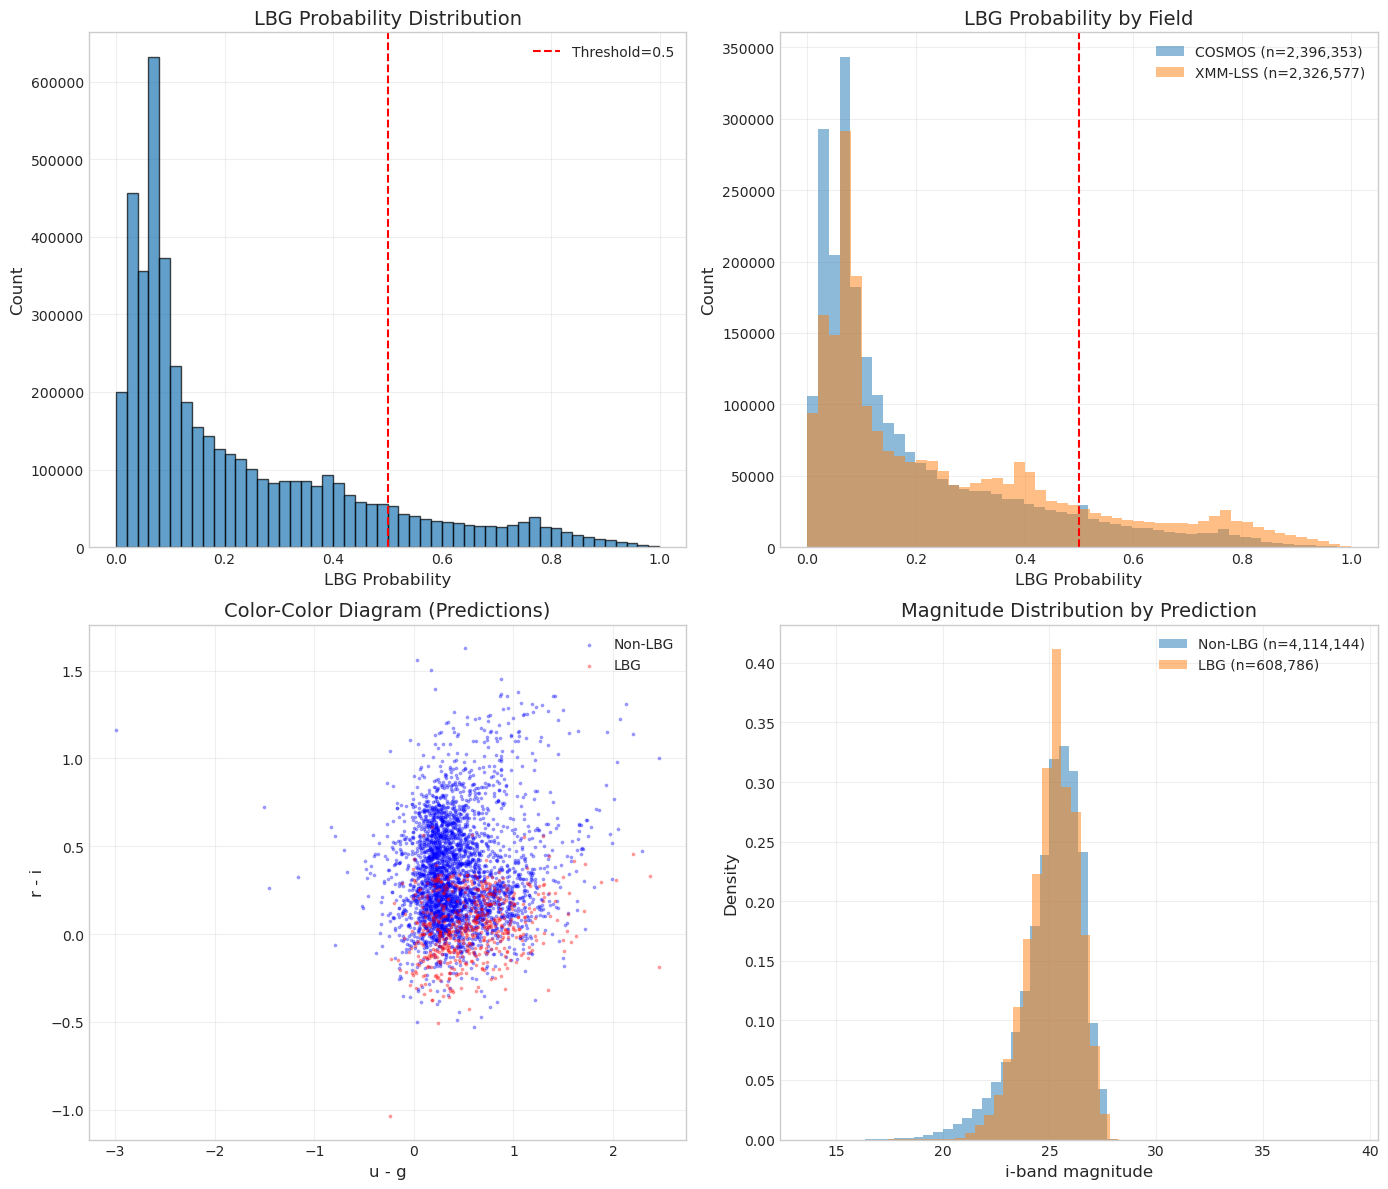

In [11]:
# Cell 10: Visualization - Prediction Distribution

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Probability histogram
ax1 = axes[0, 0]
ax1.hist(df_all['lbg_prob'], bins=50, edgecolor='black', alpha=0.7)
ax1.axvline(0.5, color='red', linestyle='--', label='Threshold=0.5')
ax1.set_xlabel('LBG Probability', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('LBG Probability Distribution', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Probability by field
ax2 = axes[0, 1]
for field in df_all['field']. unique():
    data = df_all[df_all['field'] == field]['lbg_prob']
    ax2.hist(data, bins=50, alpha=0.5, label=f'{field} (n={len(data):,})')
ax2.axvline(0.5, color='red', linestyle='--')
ax2.set_xlabel('LBG Probability', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('LBG Probability by Field', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Color-color diagram with predictions
ax3 = axes[1, 0]
lbg_mask = df_all['lbg_pred'] == 1
non_lbg_mask = df_all['lbg_pred'] == 0

# Sample for visualization
sample_size = min(10000, len(df_all))
sample_idx = np.random.choice(len(df_all), sample_size, replace=False)
df_sample = df_all.iloc[sample_idx]

ax3.scatter(df_sample[df_sample['lbg_pred']==0]['u_g'], 
            df_sample[df_sample['lbg_pred']==0]['r_i'],
            alpha=0.3, s=3, label='Non-LBG', c='blue')
ax3.scatter(df_sample[df_sample['lbg_pred']==1]['u_g'], 
            df_sample[df_sample['lbg_pred']==1]['r_i'],
            alpha=0.3, s=3, label='LBG', c='red')
ax3.set_xlabel('u - g', fontsize=12)
ax3.set_ylabel('r - i', fontsize=12)
ax3.set_title('Color-Color Diagram (Predictions)', fontsize=14)
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Magnitude distribution
ax4 = axes[1, 1]
ax4.hist(df_all[non_lbg_mask]['mag_i']. dropna(), bins=50, alpha=0.5, 
         label=f'Non-LBG (n={non_lbg_mask.sum():,})', density=True)
ax4.hist(df_all[lbg_mask]['mag_i'].dropna(), bins=50, alpha=0.5, 
         label=f'LBG (n={lbg_mask.sum():,})', density=True)
ax4.set_xlabel('i-band magnitude', fontsize=12)
ax4.set_ylabel('Density', fontsize=12)
ax4.set_title('Magnitude Distribution by Prediction', fontsize=14)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig(os.path.join(PREDICTION_DIR, f'prediction_analysis_{timestamp}.png'), 
            # dpi=150, bbox_inches='tight')
plt.show()

# print(f"\n✓ Figure saved: {PREDICTION_DIR}/prediction_analysis_{timestamp}.png")

In [12]:
# Cell 11: High-Confidence LBG Candidates

print("=" * 70)
print("HIGH-CONFIDENCE LBG CANDIDATES")
print("=" * 70)

# Different probability thresholds
thresholds = [0.5, 0.7, 0.8, 0.9]

print("\nLBG candidates at different thresholds:")
print("-" * 50)
print(f"{'Threshold':<12} {'N_LBG':<12} {'Percentage':<12}")
print("-" * 50)

for thresh in thresholds:
    n_lbg = (df_all['lbg_prob'] >= thresh).sum()
    pct = n_lbg / len(df_all) * 100
    print(f"{thresh:<12.1f} {n_lbg:<12,} {pct:<12.2f}%")

# Save high-confidence candidates (prob >= 0.8)
high_conf_mask = df_all['lbg_prob'] >= 0.8
df_high_conf = df_all[high_conf_mask]. copy()
df_high_conf = df_high_conf.sort_values('lbg_prob', ascending=False)

high_conf_path = os.path.join(PREDICTION_DIR, f"lbg_candidates_high_conf_{timestamp}.csv")
df_high_conf.to_csv(high_conf_path, index=False)

print(f"\n✓ High-confidence candidates (prob >= 0.8) saved: {high_conf_path}")
print(f"  Total:  {len(df_high_conf):,} candidates")

# Preview
print("\nTop 10 highest probability candidates:")
print(df_high_conf[['ID', 'RA', 'DEC', 'field', 'lbg_prob', 'mag_i', 'u_g', 'r_i']].head(10).to_string())

HIGH-CONFIDENCE LBG CANDIDATES

LBG candidates at different thresholds:
--------------------------------------------------
Threshold    N_LBG        Percentage  
--------------------------------------------------
0.5          608,786      12.89       %
0.7          258,156      5.47        %
0.8          106,962      2.26        %
0.9          24,937       0.53        %

✓ High-confidence candidates (prob >= 0.8) saved: ../predictions/lbg_candidates_high_conf_20260102_010109.csv
  Total:  106,962 candidates

Top 10 highest probability candidates:
              ID         RA       DEC    field  lbg_prob      mag_i       u_g       r_i
4500759  4777335  35.191071 -4.172971  XMM-LSS  0.999247  24.357650  1.854275 -0.164467
3485814  2265824  35.462404 -5.253909  XMM-LSS  0.998782  24.396224  2.848644 -0.382805
3455555  2232135  35.547873 -5.745613  XMM-LSS  0.998777  24.371462  0.848515 -0.126055
3949278  3285877  36.648803 -4.936644  XMM-LSS  0.998526  23.853704  2.654415  0.041773
4386095

In [13]:
# Cell 12: Final Summary

print("=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

print(f"""
MODEL INFORMATION
  Model: LightGBM ({BEST_MODEL_NAME})
  Features: {len(BEST_FEATURES)} features
  Training samples: {len(df_train):,}
  Training AUC: {roc_auc_score(y, y_pred_proba):.4f}

PREDICTION RESULTS
  Total sources processed: {len(df_all):,}
    - COSMOS: {len(df_cosmos):,}
    - XMM-LSS: {len(df_xmm):,}
  
  Predicted LBG (prob >= 0.5): {(df_all['lbg_prob'] >= 0.5).sum():,}
  Predicted LBG (prob >= 0.7): {(df_all['lbg_prob'] >= 0.7).sum():,}
  Predicted LBG (prob >= 0.8): {(df_all['lbg_prob'] >= 0.8).sum():,}
  Predicted LBG (prob >= 0.9): {(df_all['lbg_prob'] >= 0.9).sum():,}

SAVED FILES
  Model: {model_path}
  Config: {config_path}
  Features: {features_path}
  Feature Importance: {importance_path}
  
  Predictions (COSMOS): {PREDICTION_DIR}/predictions_COSMOS_{timestamp}.csv
  Predictions (XMM): {PREDICTION_DIR}/predictions_XMM_{timestamp}.csv
  Predictions (All): {combined_path}
  High-confidence: {high_conf_path}
  
  Figures:  {PREDICTION_DIR}/prediction_analysis_{timestamp}.png
""")

print("=" * 70)
print("✓ PIPELINE COMPLETE")
print("=" * 70)

FINAL SUMMARY

MODEL INFORMATION
  Model: LightGBM (core_err)
  Features: 12 features
  Training samples: 3,496
  Training AUC: 0.9994

PREDICTION RESULTS
  Total sources processed: 4,722,930
    - COSMOS: 2,396,353
    - XMM-LSS: 2,326,577
  
  Predicted LBG (prob >= 0.5): 608,786
  Predicted LBG (prob >= 0.7): 258,156
  Predicted LBG (prob >= 0.8): 106,962
  Predicted LBG (prob >= 0.9): 24,937

SAVED FILES
  Model: ../models/lbg_classifier_final_20260102_010109.txt
  Config: ../models/config_20260102_010109.json
  Features: ../models/features_20260102_010109.txt
  Feature Importance: ../models/feature_importance_20260102_010109.csv
  
  Predictions (COSMOS): ../predictions/predictions_COSMOS_20260102_010109.csv
  Predictions (XMM): ../predictions/predictions_XMM_20260102_010109.csv
  Predictions (All): ../predictions/predictions_all_20260102_010109.csv
  High-confidence: ../predictions/lbg_candidates_high_conf_20260102_010109.csv
  
  Figures:  ../predictions/prediction_analysis_2026